In [ ]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=579)

X = dataset.data.features
y = dataset.data.targets

X = X.fillna(X.median())

Masshtablash va "Scree Plot"

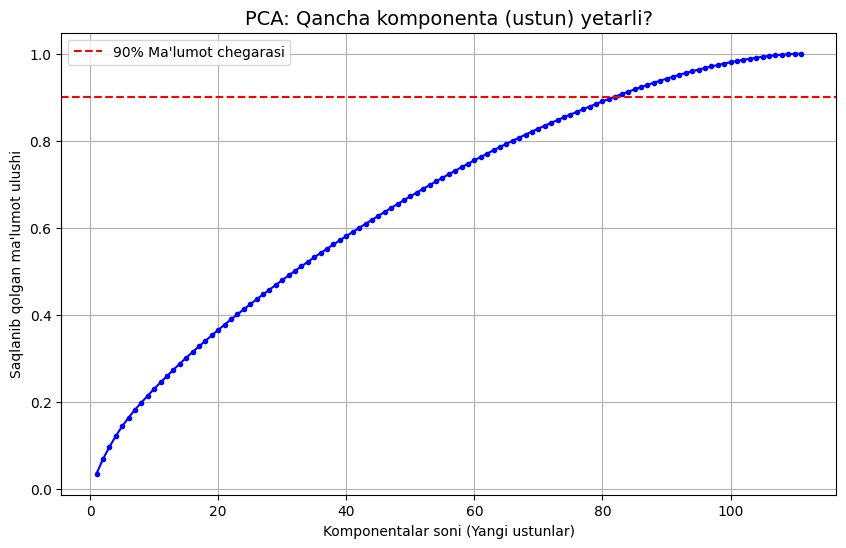

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Ma'lumotlarni masshtablash (Tarozini tenglash)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 4. Scree Plot (Grafik) chizish
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='-', color='b')

# 90% lik chegarani qizil chiziq bilan belgilaymiz
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Ma\'lumot chegarasi')

plt.title('PCA: Qancha komponenta (ustun) yetarli?', fontsize=14)
plt.xlabel('Komponentalar soni (Yangi ustunlar)')
plt.ylabel('Saqlanib qolgan ma\'lumot ulushi')
plt.grid(True)
plt.legend()
plt.show()

2D fazoga tushirish va Vizualizatsiya

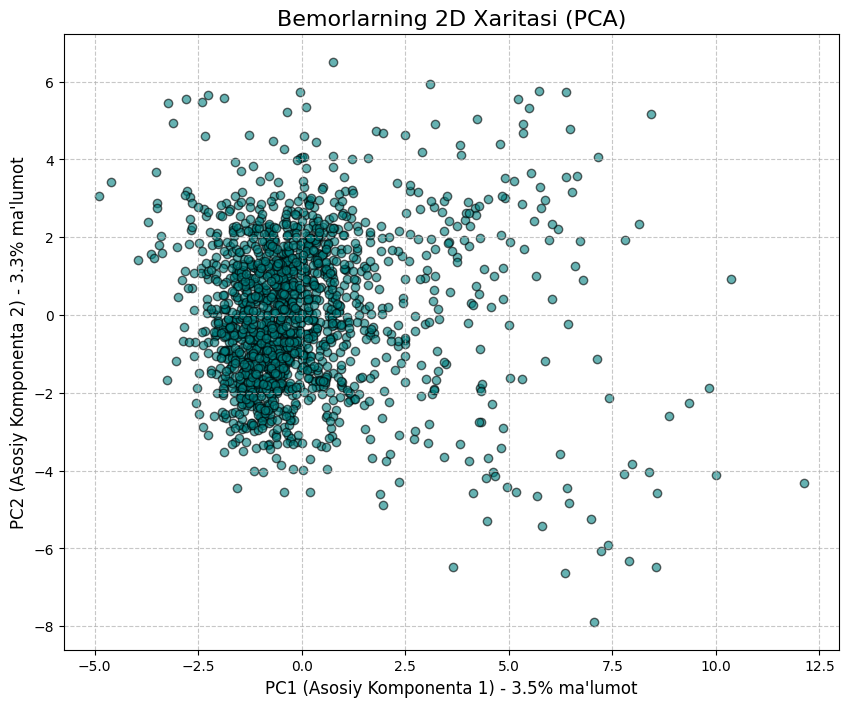

In [ ]:
# 1. Inson ko'zi ko'ra olishi uchun PCA ni 2 ta komponentga o'rnatamiz
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 2. Yangi, qisqargan ma'lumotlarni Pandas jadvaliga aylantiramiz
pca_df = pd.DataFrame(data = X_pca_2d, columns = ['PC1', 'PC2'])

# 3. Bemolarning 2D xaritasini chizamiz
plt.figure(figsize=(10, 8))
# Nuqtalarni chizish (har bir nuqta bitta bemor)
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, color='teal', edgecolors='black')

# PC1 va PC2 asl ma'lumotning necha foizini saqlab qolganini yozib qo'yamiz
pc1_var = pca_2d.explained_variance_ratio_[0] * 100
pc2_var = pca_2d.explained_variance_ratio_[1] * 100

plt.title('Bemorlarning 2D Xaritasi (PCA)', fontsize=16)
plt.xlabel(f"PC1 (Asosiy Komponenta 1) - {pc1_var:.1f}% ma'lumot", fontsize=12)
plt.ylabel(f"PC2 (Asosiy Komponenta 2) - {pc2_var:.1f}% ma'lumot", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Feature Loadings (Vaznlar) tahlili

/tmp/ipykernel_490/4136562685.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vazn', y='Tibbiy_Belgi', data=top_10_features, palette='coolwarm')


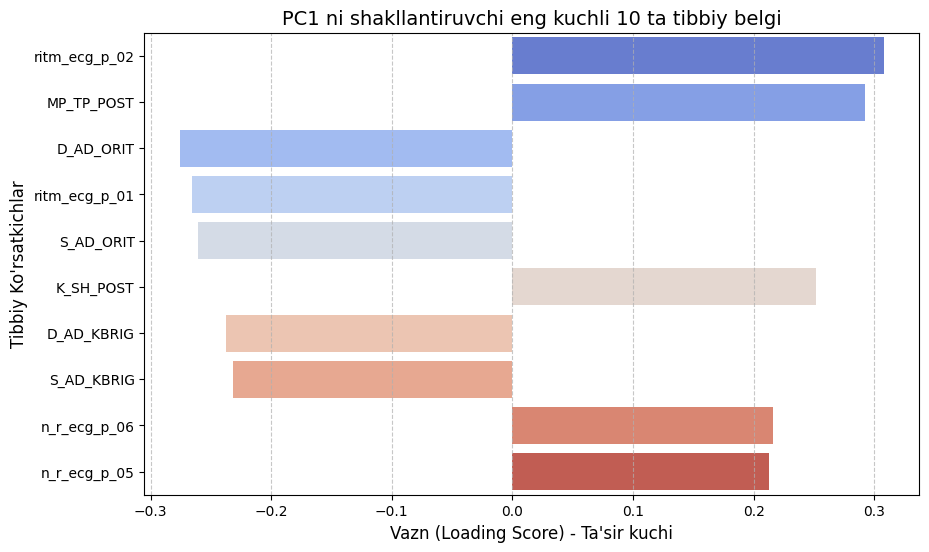

PC1 ga eng kuchli ta'sir qiluvchi belgilar:


,Tibbiy_Belgi,Vazn
49,ritm_ecg_p_02,0.308198
39,MP_TP_POST,0.292195
36,D_AD_ORIT,-0.275918
48,ritm_ecg_p_01,-0.265894
35,S_AD_ORIT,-0.261050
38,K_SH_POST,0.251659
34,D_AD_KBRIG,-0.237861
33,S_AD_KBRIG,-0.231290
59,n_r_ecg_p_06,0.216202
58,n_r_ecg_p_05,0.212775


In [ ]:
import seaborn as sns

# 1. PC1 uchun barcha 111 ta ustunning vaznlarini (loadings) olamiz
pc1_loadings = pca_2d.components_[0]

# 2. Ularni o'qishga qulay bo'lishi uchun Pandas jadvaliga joylaymiz
# X.columns orqali original ustun nomlarini olamiz
loadings_df = pd.DataFrame({
    'Tibbiy_Belgi': X.columns,
    'Vazn': pc1_loadings,
    'Absolyut_Vazn': np.abs(pc1_loadings) # Manfiy va musbat ta'sirlarni bir xil baholash uchun
})

# 3. Eng kuchli ta'sir qiluvchi 10 ta belgini ajratib olamiz
top_10_features = loadings_df.sort_values(by='Absolyut_Vazn', ascending=False).head(10)

# 4. Vizualizatsiya (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='Vazn', y='Tibbiy_Belgi', data=top_10_features, palette='coolwarm')

plt.title('PC1 ni shakllantiruvchi eng kuchli 10 ta tibbiy belgi', fontsize=14)
plt.xlabel('Vazn (Loading Score) - Ta\'sir kuchi', fontsize=12)
plt.ylabel('Tibbiy Ko\'rsatkichlar', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Jadval ko'rinishida ham chiqaramiz
print("PC1 ga eng kuchli ta'sir qiluvchi belgilar:")
display(top_10_features[['Tibbiy_Belgi', 'Vazn']])

Bemorlar ahvolini baholovchi "Radar" (Colored Scatter Plot)

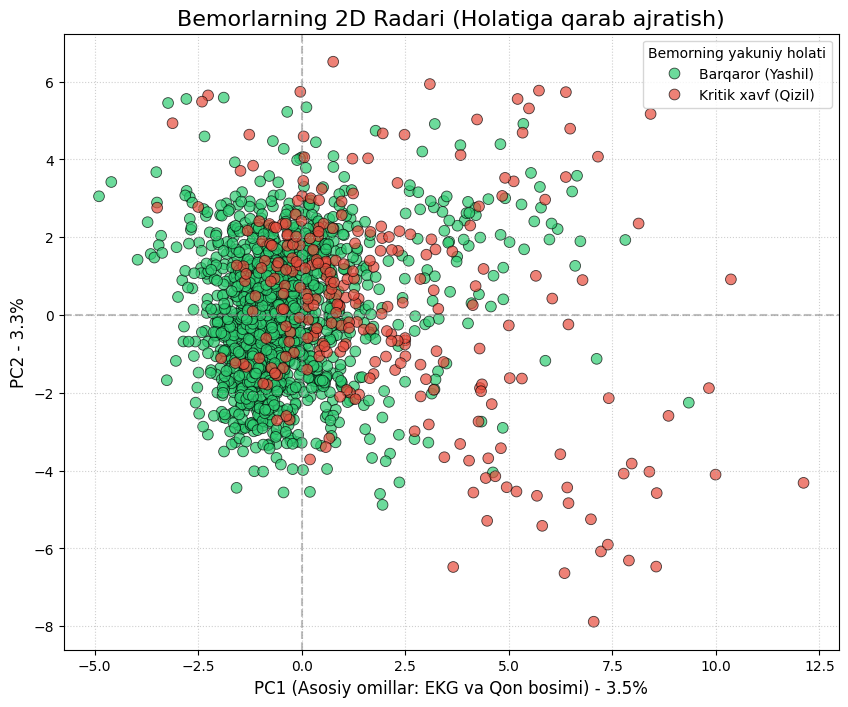

In [ ]:
import seaborn as sns

# 1. Target (maqsadli) o'zgaruvchini tayyorlaymiz.
# 'LET_IS' - O'lim holati (0 = tirik/barqaror, 1 va undan baland = xavfli/vafot etgan)
if 'LET_IS' in y.columns:
    target = y['LET_IS'].fillna(0) # Bo'sh joylarni 0 deb olamiz
else:
    target = y.iloc[:, -1].fillna(0) # Agar nom o'zgargan bo'lsa, oxirgi ustunni olamiz

# Oson tushunish uchun faqat 2 ta guruhga ajratamiz: 0 (Yaxshi) va 1 (Kritik xavf)
target_binary = (target > 0).astype(int)

# 2. PCA ma'lumotlar jadvalimizga bu ma'lumotni qo'shamiz
pca_df['Holati'] = target_binary
pca_df['Holati'] = pca_df['Holati'].map({0: 'Barqaror (Yashil)', 1: 'Kritik xavf (Qizil)'})

# 3. Rangli "Radar" grafigini chizamiz
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Holati',
    palette=['#2ecc71', '#e74c3c'], # Yashil (2ecc71) va Qizil (e74c3c)
    data=pca_df,
    alpha=0.7,
    s=60,
    edgecolor='black'
)

# 4. Grafik bezaklari
plt.title('Bemorlarning 2D Radari (Holatiga qarab ajratish)', fontsize=16)
plt.xlabel(f"PC1 (Asosiy omillar: EKG va Qon bosimi) - {pc1_var:.1f}%", fontsize=12)
plt.ylabel(f"PC2 - {pc2_var:.1f}%", fontsize=12)
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Bemorning yakuniy holati', loc='upper right')
plt.show()